# Loan Default Prediction using XGBoost on Home Credit Data

Predicting whether a loan applicant will default, using real data from the Home Credit Default Risk dataset (Kaggle).

We compare XGBoost, LightGBM, CatBoost and Random Forest, and test how adding more features improves prediction.

In [1]:
!pip install pandas numpy scikit-learn xgboost lightgbm catboost shap matplotlib seaborn -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Loading the dataset

Home Credit has multiple CSV files. The main one is `application_train.csv` with 307k loan applications.

In [3]:
app = pd.read_csv('home_credit/application_train.csv')
print(f'Applications: {len(app):,} rows, {len(app.columns)} columns')
print(f'Target (DEFAULT): {app["TARGET"].value_counts().to_dict()}')
print(f'Default rate: {app["TARGET"].mean():.1%}')

Applications: 307,511 rows, 122 columns
Target (DEFAULT): {0: 282686, 1: 24825}
Default rate: 8.1%


In [4]:
app.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# check missing values in the most important columns
missing = app.isnull().sum()
missing_pct = (missing / len(app) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
print('Columns with >10% missing:')
print(missing_df[missing_df['Pct'] > 10].sort_values('Pct', ascending=False).head(20))

Columns with >10% missing:
                          Missing   Pct
COMMONAREA_AVG             214865  69.9
COMMONAREA_MODE            214865  69.9
COMMONAREA_MEDI            214865  69.9
NONLIVINGAPARTMENTS_MODE   213514  69.4
NONLIVINGAPARTMENTS_AVG    213514  69.4
NONLIVINGAPARTMENTS_MEDI   213514  69.4
LIVINGAPARTMENTS_MODE      210199  68.4
LIVINGAPARTMENTS_AVG       210199  68.4
LIVINGAPARTMENTS_MEDI      210199  68.4
FONDKAPREMONT_MODE         210295  68.4
FLOORSMIN_MEDI             208642  67.8
FLOORSMIN_MODE             208642  67.8
FLOORSMIN_AVG              208642  67.8
YEARS_BUILD_AVG            204488  66.5
YEARS_BUILD_MODE           204488  66.5
YEARS_BUILD_MEDI           204488  66.5
OWN_CAR_AGE                202929  66.0
LANDAREA_MEDI              182590  59.4
LANDAREA_MODE              182590  59.4
LANDAREA_AVG               182590  59.4


## 2. Data exploration

In [6]:
print('Contract types:')
print(app['NAME_CONTRACT_TYPE'].value_counts())
print()
print('Gender:')
print(app['CODE_GENDER'].value_counts())
print()
print('Income types:')
print(app['NAME_INCOME_TYPE'].value_counts())

Contract types:
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

Gender:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

Income types:
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64


In [7]:
# default rate by contract type and income type
print('Default rate by contract type:')
print(app.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean().round(3))
print()
print('Default rate by income type:')
print(app.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False).round(3))

Default rate by contract type:


NAME_CONTRACT_TYPE
Cash loans         0.083
Revolving loans    0.055
Name: TARGET, dtype: float64

Default rate by income type:


NAME_INCOME_TYPE
Maternity leave         0.400
Unemployed              0.364
Working                 0.096
Commercial associate    0.075
State servant           0.058
Pensioner               0.054
Businessman             0.000
Student                 0.000
Name: TARGET, dtype: float64


In [8]:
print(f'Income - mean: {app["AMT_INCOME_TOTAL"].mean():,.0f}, median: {app["AMT_INCOME_TOTAL"].median():,.0f}')
print(f'Credit amount - mean: {app["AMT_CREDIT"].mean():,.0f}, median: {app["AMT_CREDIT"].median():,.0f}')
print(f'Annuity - mean: {app["AMT_ANNUITY"].mean():,.0f}, median: {app["AMT_ANNUITY"].median():,.0f}')

Income - mean: 168,798, median: 147,150
Credit amount - mean: 599,026, median: 513,531
Annuity - mean: 27,109, median: 24,903


## 3. Data cleaning

DAYS_EMPLOYED has an anomaly: 365,243 days (~1000 years) means the person is unemployed/retired. We flag it separately.

In [9]:
# fix the DAYS_EMPLOYED anomaly
print(f'DAYS_EMPLOYED anomaly (365243): {(app["DAYS_EMPLOYED"] == 365243).sum():,} rows ({(app["DAYS_EMPLOYED"] == 365243).mean():.1%})')

app['DAYS_EMPLOYED_ANOM'] = (app['DAYS_EMPLOYED'] == 365243).astype(int)
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, np.nan)

# convert negative days to positive for readability
app['AGE_YEARS'] = (-app['DAYS_BIRTH'] / 365.25).round(1)
app['EMPLOYMENT_YEARS'] = (-app['DAYS_EMPLOYED'] / 365.25).round(1)

print(f'Age range: {app["AGE_YEARS"].min():.0f} to {app["AGE_YEARS"].max():.0f} years')
print(f'Employment years - mean: {app["EMPLOYMENT_YEARS"].mean():.1f}, median: {app["EMPLOYMENT_YEARS"].median():.1f}')

DAYS_EMPLOYED anomaly (365243): 55,374 rows (18.0%)
Age range: 20 to 69 years
Employment years - mean: 6.5, median: 4.5


In [10]:
# derived financial ratios - these are usually strong predictors
app['CREDIT_INCOME_RATIO'] = app['AMT_CREDIT'] / (app['AMT_INCOME_TOTAL'] + 1)
app['ANNUITY_INCOME_RATIO'] = app['AMT_ANNUITY'] / (app['AMT_INCOME_TOTAL'] + 1)
app['CREDIT_GOODS_RATIO'] = app['AMT_CREDIT'] / (app['AMT_GOODS_PRICE'] + 1)
app['INCOME_PER_PERSON'] = app['AMT_INCOME_TOTAL'] / (app['CNT_FAM_MEMBERS'] + 1)

print('Derived features created:')
print(f'  Credit/Income ratio - mean: {app["CREDIT_INCOME_RATIO"].mean():.2f}')
print(f'  Annuity/Income ratio - mean: {app["ANNUITY_INCOME_RATIO"].mean():.4f}')
print(f'  Income per person - mean: {app["INCOME_PER_PERSON"].mean():,.0f}')

Derived features created:
  Credit/Income ratio - mean: 3.96
  Annuity/Income ratio - mean: 0.1809
  Income per person - mean: 57,482


## 4. Feature engineering from supplementary tables

Aggregating key info from bureau and previous application files to enrich each applicant's profile.

In [11]:
bureau = pd.read_csv('home_credit/bureau.csv')
print(f'Bureau records: {len(bureau):,}')

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    NUM_BUREAU_CREDITS=('SK_ID_BUREAU', 'count'),
    AVG_BUREAU_CREDIT=('AMT_CREDIT_SUM', 'mean'),
    TOTAL_BUREAU_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
    NUM_BUREAU_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', lambda x: (x > 0).sum()),
    AVG_BUREAU_DAYS_CREDIT=('DAYS_CREDIT', 'mean'),
).reset_index()

app = app.merge(bureau_agg, on='SK_ID_CURR', how='left')
for col in bureau_agg.columns[1:]:
    app[col] = app[col].fillna(0)

print(f'Bureau features added for {bureau_agg["SK_ID_CURR"].nunique():,} applicants')
del bureau

Bureau records: 1,716,428


Bureau features added for 305,811 applicants


In [12]:
prev = pd.read_csv('home_credit/previous_application.csv')
print(f'Previous applications: {len(prev):,}')

prev_agg = prev.groupby('SK_ID_CURR').agg(
    NUM_PREV_APPS=('SK_ID_PREV', 'count'),
    PREV_APPROVAL_RATE=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').mean()),
    AVG_PREV_CREDIT=('AMT_CREDIT', 'mean'),
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
).reset_index()

app = app.merge(prev_agg, on='SK_ID_CURR', how='left')
for col in prev_agg.columns[1:]:
    app[col] = app[col].fillna(0)

print(f'Previous app features added for {prev_agg["SK_ID_CURR"].nunique():,} applicants')
del prev

Previous applications: 1,670,214


Previous app features added for 338,857 applicants


## 5. Setting up feature matrix

We define 4 feature sets to test how adding more info improves prediction:
- 5 basic financial
- 10 with external scores and ratios
- 16 with personal/behavioral
- 25 with bureau + previous app history

In [13]:
FEATURES_5 = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AGE_YEARS', 'EMPLOYMENT_YEARS',
]

FEATURES_10 = FEATURES_5 + [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
]

FEATURES_16 = FEATURES_10 + [
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'INCOME_PER_PERSON', 'DAYS_EMPLOYED_ANOM',
]

FEATURES_ALL = FEATURES_16 + [
    'CREDIT_GOODS_RATIO', 'AMT_GOODS_PRICE',
    'REGION_POPULATION_RELATIVE',
    'NUM_BUREAU_CREDITS', 'AVG_BUREAU_CREDIT',
    'TOTAL_BUREAU_DEBT', 'NUM_BUREAU_OVERDUE',
    'NUM_PREV_APPS', 'PREV_APPROVAL_RATE',
]

print(f'Feature sets: {len(FEATURES_5)}, {len(FEATURES_10)}, {len(FEATURES_16)}, {len(FEATURES_ALL)}')

Feature sets: 5, 10, 16, 25


In [14]:
# fill missing values for the features we'll use
for col in FEATURES_ALL:
    if app[col].isnull().any():
        median_val = app[col].median()
        missing_count = app[col].isnull().sum()
        app[col] = app[col].fillna(median_val)
        print(f'  {col}: filled {missing_count:,} missing with median {median_val:.2f}')

X = app[FEATURES_ALL]
y = app['TARGET']

print(f'\nDataset: {X.shape[0]:,} rows, {X.shape[1]} features')
print(f'Default rate: {y.mean():.1%}')

  AMT_ANNUITY: filled 12 missing with median 24903.00
  EMPLOYMENT_YEARS: filled 55,374 missing with median 4.50
  EXT_SOURCE_1: filled 173,378 missing with median 0.51
  EXT_SOURCE_2: filled 660 missing with median 0.57
  EXT_SOURCE_3: filled 60,965 missing with median 0.54
  ANNUITY_INCOME_RATIO: filled 12 missing with median 0.16
  CNT_FAM_MEMBERS: filled 2 missing with median 2.00
  INCOME_PER_PERSON: filled 2 missing with median 49500.00
  CREDIT_GOODS_RATIO: filled 278 missing with median 1.12
  AMT_GOODS_PRICE: filled 278 missing with median 450000.00

Dataset: 307,511 rows, 25 features
Default rate: 8.1%


## 6. Train-test split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f'Train set: {len(X_train):,} rows ({y_train.mean():.1%} default)')
print(f'Test set:  {len(X_test):,} rows ({y_test.mean():.1%} default)')

Train set: 215,257 rows (8.1% default)
Test set:  92,254 rows (8.1% default)


## 7. Training XGBoost

In [16]:
from xgboost import XGBClassifier

# heavy class imbalance (8% default) so we need scale_pos_weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {pos_weight:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

xgb.fit(X_train, y_train)
print('Model trained')

scale_pos_weight = 11.39


Model trained


## 8. Predictions

In [17]:
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

sample = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Probability': np.round(y_proba[:10], 4),
    'Correct': y_test.values[:10] == y_pred[:10]
})
sample

,Actual,Predicted,Probability,Correct
0,0,0,0.3316,True
1,0,0,0.4664,True
2,0,0,0.4445,True
3,0,0,0.1562,True
4,0,1,0.6653,False
5,0,1,0.7884,False
6,0,0,0.3677,True
7,0,0,0.2095,True
8,0,0,0.1514,True
9,0,0,0.3955,True


## 9. Evaluation

In [18]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

              precision    recall  f1-score   support

  No Default       0.96      0.73      0.83     84806
     Default       0.17      0.64      0.27      7448

    accuracy                           0.72     92254
   macro avg       0.57      0.69      0.55     92254
weighted avg       0.90      0.72      0.78     92254



In [19]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
}

for name, val in metrics.items():
    print(f'{name}: {val:.4f}')

Accuracy: 0.7241
Precision: 0.1736
Recall: 0.6430
F1: 0.2734
ROC-AUC: 0.7527


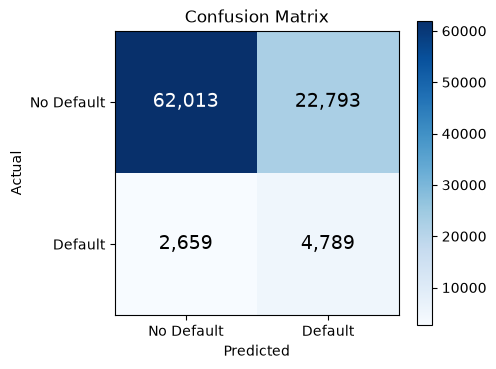

TN=62,013  FP=22,793
FN=2,659  TP=4,789


In [20]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=14, color=color)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['No Default', 'Default'])
ax.set_yticklabels(['No Default', 'Default'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f'TN={cm[0,0]:,}  FP={cm[0,1]:,}')
print(f'FN={cm[1,0]:,}  TP={cm[1,1]:,}')

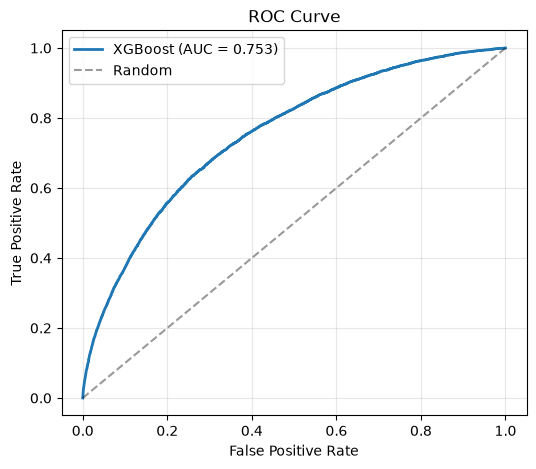

In [21]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {auc_val:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Cross validation

5-fold stratified CV to confirm the result is stable.

In [22]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    fold_xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train.iloc[tr_idx]==0).sum()/(y_train.iloc[tr_idx]==1).sum(),
        eval_metric='logloss', random_state=42, verbosity=0
    )
    fold_xgb.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    fold_proba = fold_xgb.predict_proba(X_train.iloc[val_idx])[:, 1]
    fold_auc = roc_auc_score(y_train.iloc[val_idx], fold_proba)
    cv_scores.append(fold_auc)
    print(f'Fold {fold}: AUC = {fold_auc:.4f}')

print(f'\nMean: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})')

Fold 1: AUC = 0.7567


Fold 2: AUC = 0.7423


Fold 3: AUC = 0.7535


Fold 4: AUC = 0.7482


Fold 5: AUC = 0.7512

Mean: 0.7504 (+/- 0.0049)


## 11. Feature importance

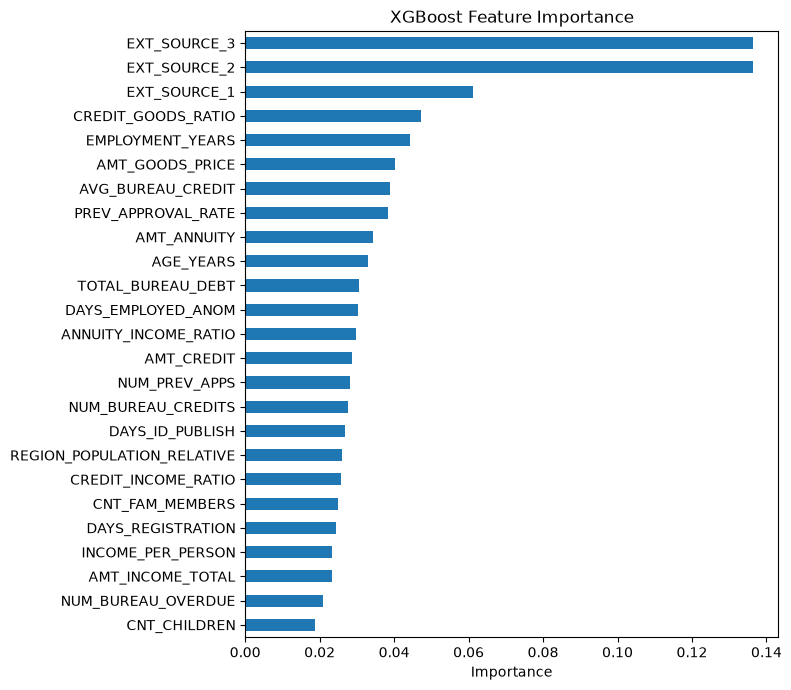

In [23]:
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES_ALL).sort_values(ascending=True)

plt.figure(figsize=(8, 7))
feat_imp.plot(kind='barh')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

## 12. SHAP analysis

SHAP tells us exactly how each feature pushes a prediction toward default or no-default.

In [24]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_vals = explainer.shap_values(X_test.iloc[:300])

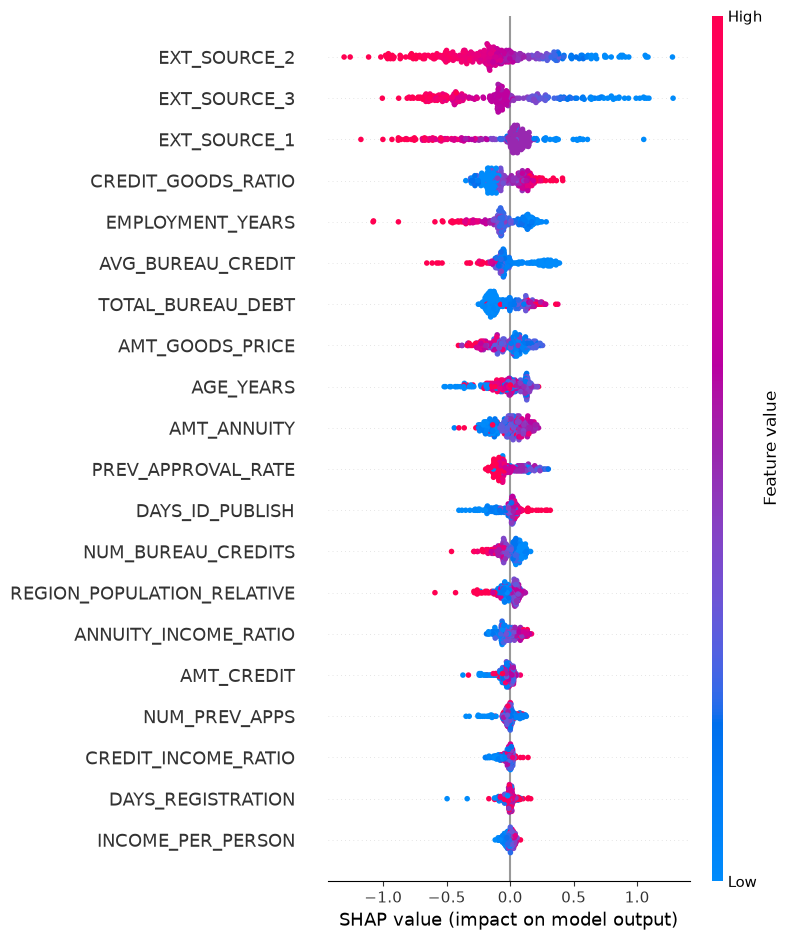

In [25]:
shap.summary_plot(shap_vals, X_test.iloc[:300], feature_names=FEATURES_ALL)

Case: actual=0, predicted=0.332


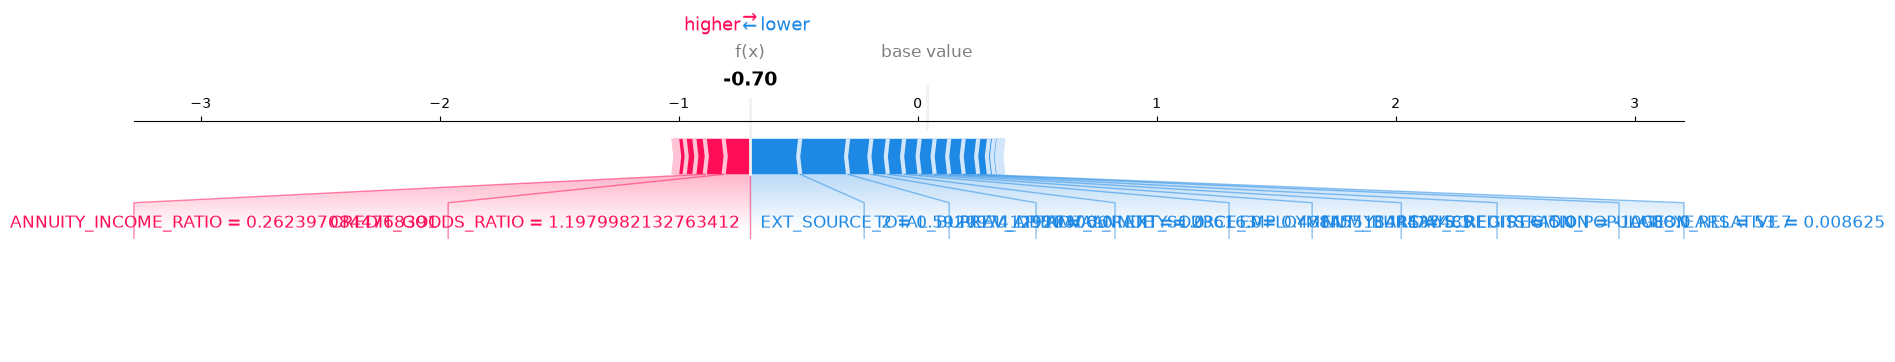

In [26]:
# explain one prediction
idx = 0
print(f'Case: actual={y_test.iloc[idx]}, predicted={y_proba[idx]:.3f}')
shap.force_plot(explainer.expected_value, shap_vals[idx],
                X_test.iloc[idx], feature_names=FEATURES_ALL, matplotlib=True)

## 13. Feature combination experiment

Testing how performance changes as we add more features.

In [27]:
combo_results = []

for label, feats in [('5 financial', FEATURES_5), ('10 +scores', FEATURES_10),
                      ('16 +behavioral', FEATURES_16), ('25 all', FEATURES_ALL)]:
    m = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric='logloss', random_state=42, verbosity=0
    )
    m.fit(X_train[feats], y_train)
    proba = m.predict_proba(X_test[feats])[:, 1]
    pred = m.predict(X_test[feats])
    
    auc = roc_auc_score(y_test, proba)
    f1 = f1_score(y_test, pred)
    combo_results.append({'Features': label, 'Count': len(feats), 'AUC': auc, 'F1': f1})
    print(f'{label:18s} ({len(feats):2d} feats) -> AUC={auc:.4f}  F1={f1:.4f}')

combo_df = pd.DataFrame(combo_results)
combo_df

5 financial        ( 5 feats) -> AUC=0.6470  F1=0.2025


10 +scores         (10 feats) -> AUC=0.7413  F1=0.2608


16 +behavioral     (16 feats) -> AUC=0.7422  F1=0.2646


25 all             (25 feats) -> AUC=0.7527  F1=0.2734


,Features,Count,AUC,F1
0,5 financial,5,0.647039,0.202533
1,10 +scores,10,0.741303,0.260820
2,16 +behavioral,16,0.742158,0.264559
3,25 all,25,0.752674,0.273423


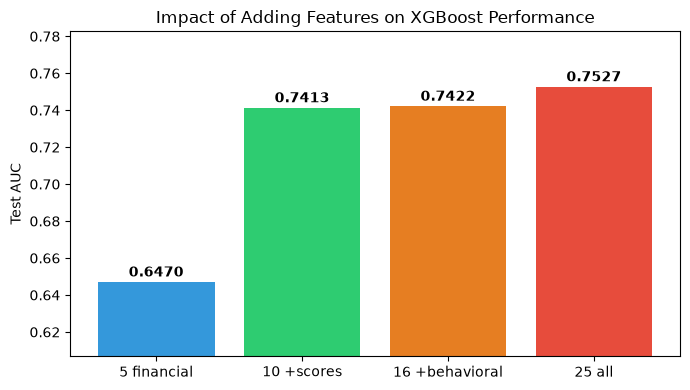

In [28]:
plt.figure(figsize=(7, 4))
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
bars = plt.bar(combo_df['Features'], combo_df['AUC'], color=colors)
for bar, val in zip(bars, combo_df['AUC']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
plt.ylabel('Test AUC')
plt.title('Impact of Adding Features on XGBoost Performance')
plt.ylim(combo_df['AUC'].min()-0.04, combo_df['AUC'].max()+0.03)
plt.tight_layout()
plt.show()

## 14. Model comparison

Comparing XGBoost against LightGBM, CatBoost, and Random Forest using all 25 features.

In [29]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        is_unbalance=True, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        auto_class_weights='Balanced', random_seed=42, verbose=0),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        class_weight='balanced', random_state=42),
}

comparison = []
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    comparison.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall': round(recall_score(y_test, pred), 4),
        'F1': round(f1_score(y_test, pred), 4),
        'AUC': round(roc_auc_score(y_test, proba), 4),
    })

comp_df = pd.DataFrame(comparison)
comp_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,XGBoost,0.7241,0.1736,0.6430,0.2734,0.7527
1,LightGBM,0.7062,0.1676,0.6653,0.2677,0.7533
2,CatBoost,0.6964,0.1647,0.6779,0.2650,0.7535
3,Random Forest,0.7469,0.1764,0.5816,0.2706,0.7410


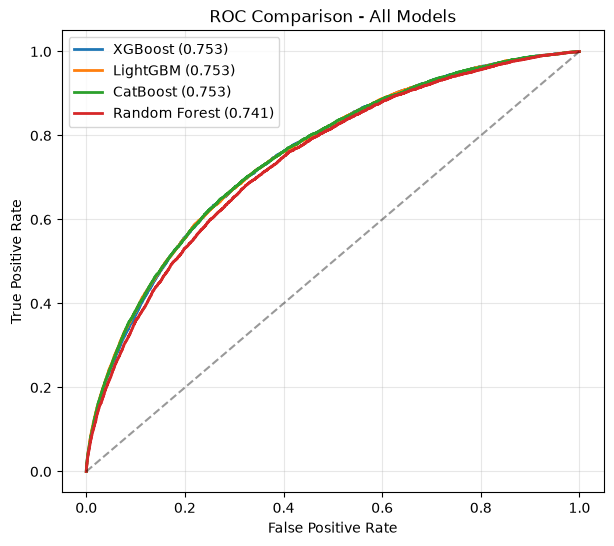

In [30]:
# ROC curves for all models
plt.figure(figsize=(7, 6))
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} ({auc:.3f})')

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison - All Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 15. Calibration

Checking if predicted probabilities match actual default rates.

In [31]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

cal_xgb = CalibratedClassifierCV(xgb, method='isotonic', cv=3)
cal_xgb.fit(X_train, y_train)
cal_proba = cal_xgb.predict_proba(X_test)[:, 1]

print(f'Brier score (raw):        {brier_score_loss(y_test, y_proba):.4f}')
print(f'Brier score (calibrated): {brier_score_loss(y_test, cal_proba):.4f}')

Brier score (raw):        0.1836
Brier score (calibrated): 0.0680


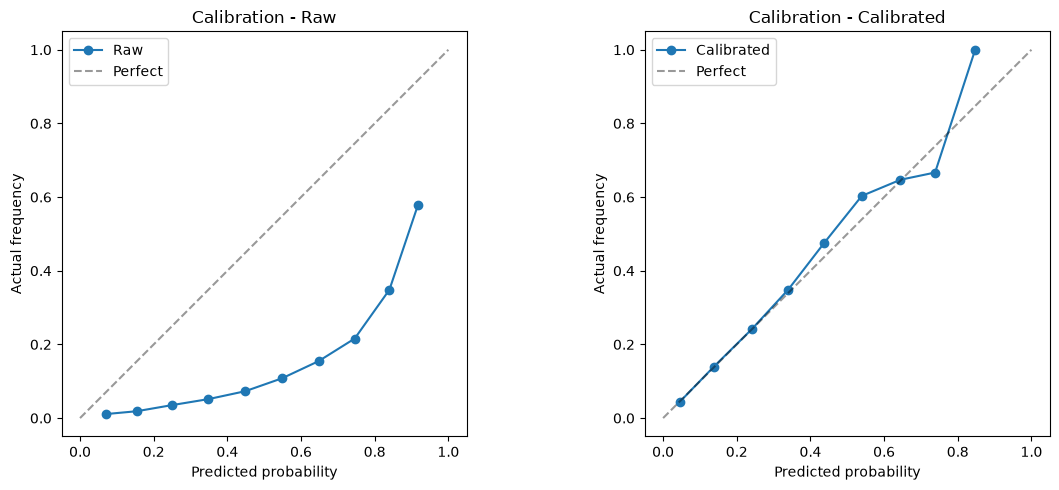

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, prob, title in [(axes[0], y_proba, 'Raw'), (axes[1], cal_proba, 'Calibrated')]:
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(prob_pred, prob_true, 'o-', label=title)
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Perfect')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Actual frequency')
    ax.set_title(f'Calibration - {title}')
    ax.legend()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 16. Precision / Recall / F1 comparison

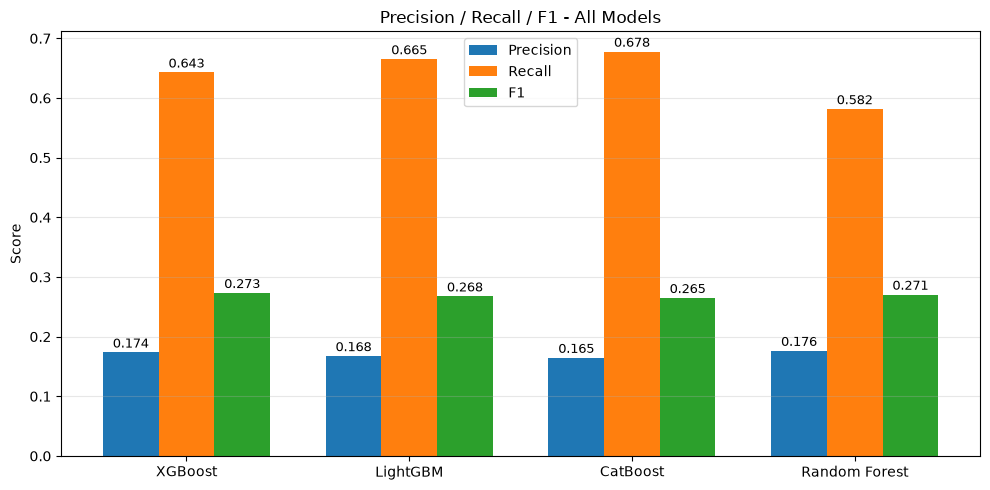

In [33]:
metrics_to_plot = ['Precision', 'Recall', 'F1']
x = np.arange(len(comp_df['Model']))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i * width, comp_df[metric], width, label=metric)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(comp_df['Model'])
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 - All Models')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Cross-validation box plot

XGBoost          mean=0.7504  std=0.0049  folds=[0.7567 0.7423 0.7535 0.7482 0.7512]


LightGBM         mean=0.7516  std=0.0048  folds=[0.7576 0.7436 0.7548 0.7499 0.7519]


CatBoost         mean=0.7521  std=0.0057  folds=[0.7574 0.742  0.7558 0.7499 0.7555]


Random Forest    mean=0.7408  std=0.0057  folds=[0.745  0.73   0.7429 0.7408 0.7454]


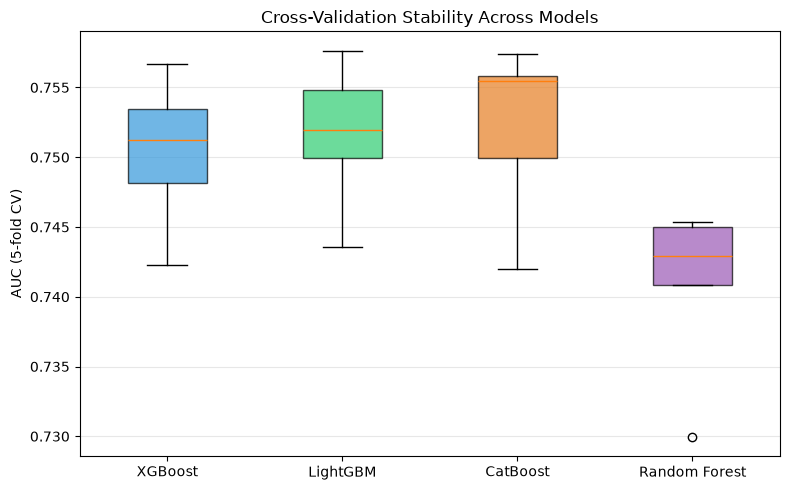

In [34]:
from sklearn.model_selection import cross_val_score

cv_all = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')
    cv_all[name] = scores
    print(f'{name:15s}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={scores.round(4)}')

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(list(cv_all.values()), patch_artist=True)
ax.set_xticks(range(1, len(cv_all) + 1))
ax.set_xticklabels(list(cv_all.keys()))

colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('AUC (5-fold CV)')
ax.set_title('Cross-Validation Stability Across Models')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Feature correlation heatmap

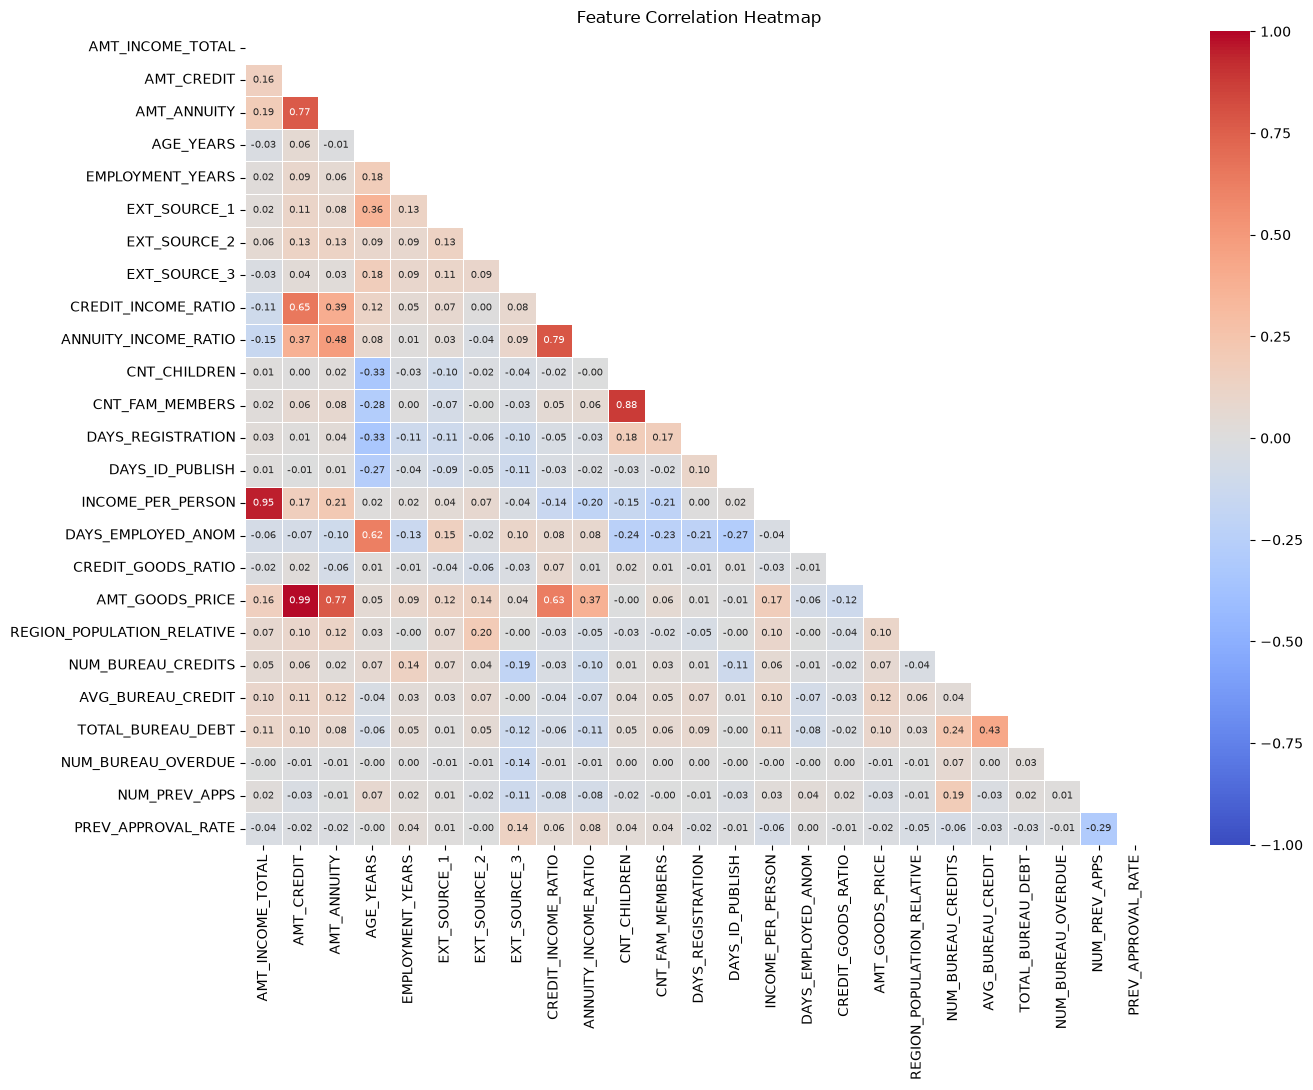

Highly correlated pairs (|r| > 0.7):
  AMT_INCOME_TOTAL  <->  INCOME_PER_PERSON  :  0.953
  AMT_CREDIT  <->  AMT_ANNUITY  :  0.77
  AMT_CREDIT  <->  AMT_GOODS_PRICE  :  0.987
  AMT_ANNUITY  <->  AMT_GOODS_PRICE  :  0.775
  CREDIT_INCOME_RATIO  <->  ANNUITY_INCOME_RATIO  :  0.788
  CNT_CHILDREN  <->  CNT_FAM_MEMBERS  :  0.879


In [35]:
import seaborn as sns

corr = X.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))
if high_corr:
    print('Highly correlated pairs (|r| > 0.7):')
    for a, b, r in high_corr:
        print(f'  {a}  <->  {b}  :  {r}')
else:
    print('No feature pairs above |0.7| correlation.')

## 19. Default distribution by income and contract type

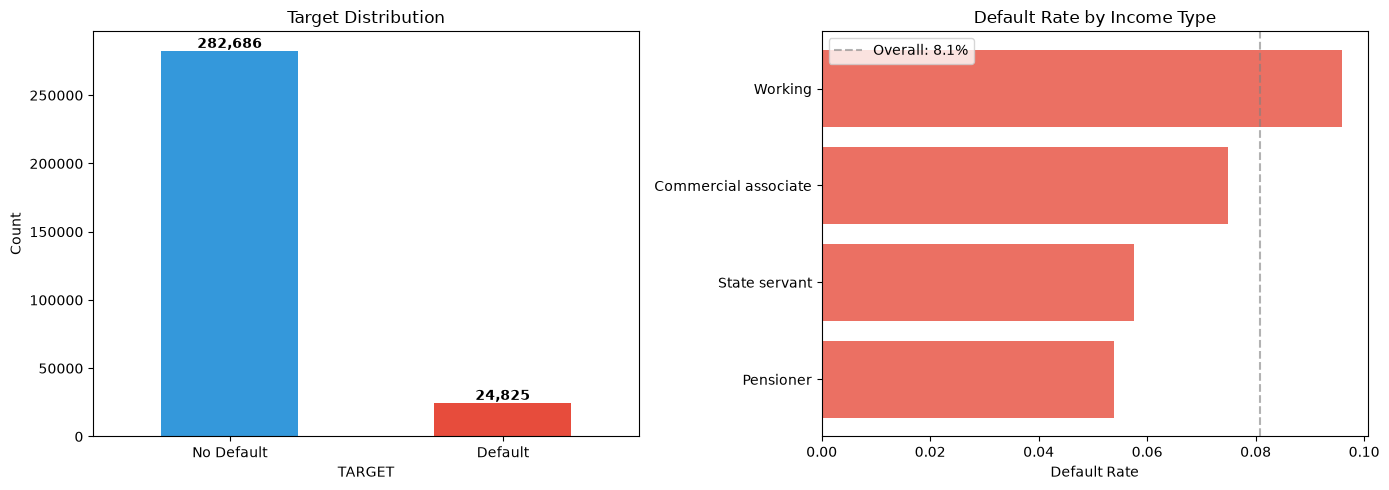

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: default count
y.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(y.value_counts().sort_index()):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# right: default rate by income type (top 6)
top_income = app.groupby('NAME_INCOME_TYPE')['TARGET'].agg(['mean', 'count'])
top_income = top_income[top_income['count'] > 100].sort_values('mean', ascending=True)
bars = axes[1].barh(top_income.index, top_income['mean'], color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Default Rate')
axes[1].set_title('Default Rate by Income Type')
axes[1].axvline(x=y.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Overall: {y.mean():.1%}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 20. Confusion matrices for all 4 models

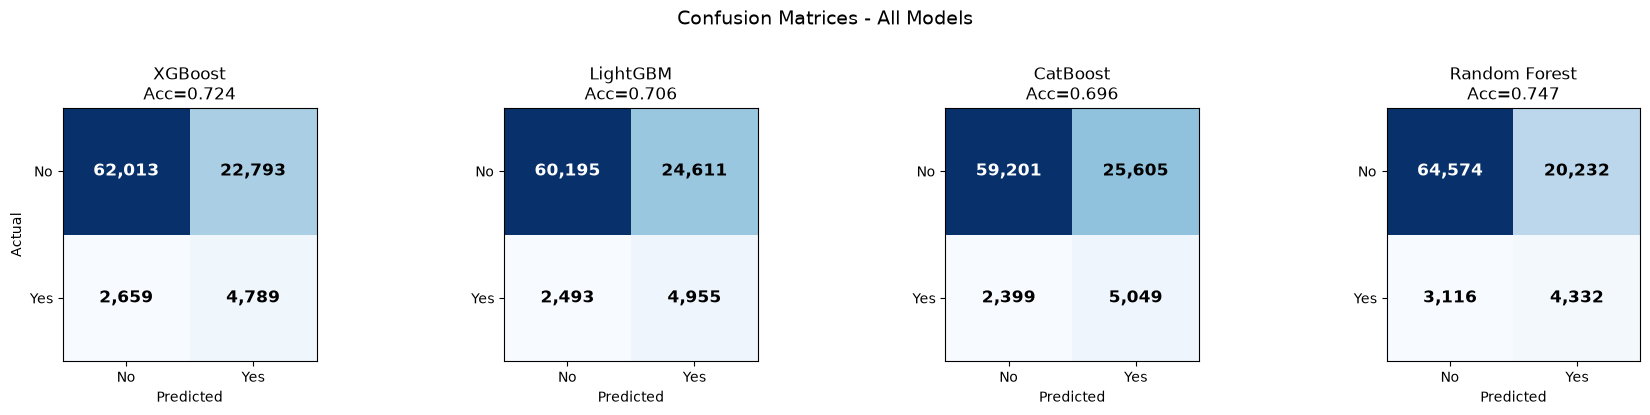

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                    fontsize=12, fontweight='bold', color=color)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No', 'Yes']); ax.set_yticklabels(['No', 'Yes'])
    ax.set_xlabel('Predicted')
    if ax == axes[0]:
        ax.set_ylabel('Actual')
    acc = accuracy_score(y_test, pred)
    ax.set_title(f'{name}\nAcc={acc:.3f}')

plt.suptitle('Confusion Matrices - All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary

- **Dataset**: Home Credit Default Risk — 307,511 loan applications, 25 engineered features from 3 tables
- **Split**: 70/30 stratified (215,257 train / 92,254 test)
- **Class imbalance**: 8.1% default rate, handled with scale_pos_weight = 11.39
- **Best model**: CatBoost AUC = 0.7535, XGBoost AUC = 0.7527 (very close)
- **CV stability**: XGBoost 5-fold AUC = 0.7504 +/- 0.0049
- **Key predictors**: EXT_SOURCE scores (biggest jump: 5 feats 0.647 -> 10 feats 0.741), credit-income ratio, age
- **Feature combination**: external scores give the biggest AUC jump (+0.094), bureau/prev app history adds another +0.01
- **Calibration**: Brier score improved from 0.1836 (raw) to 0.0680 (calibrated)